# Longitudinal hypergraph analysis

This notebook studies all available yearly municipality-company networks. Municipalities
are nodes, companies are hyperedges, and an incidence records an ownership share.
The detailed view defaults to the latest processed year, as does `scripts/run_experiment.py`.

Structural summaries use the full prepared networks, including companies with a single
municipal shareholder. The experiment runner filters companies using `min_edge_size`
(default 2), so its node and company counts can differ. This notebook describes network
structure and data quality; propagation scores and reach are in `results.ipynb` and
`influence_maximization.ipynb`.


In [1]:
from collections import Counter
from pathlib import Path
import sys
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from networkx.utils import UnionFind

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


## Configuration

Change `SELECTED_YEAR` for the detailed rankings. `DISTRIBUTION_YEARS` controls which years are overlaid in the distribution plots.

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "scripts/run_experiment.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find the project root")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from scripts.run_experiment import DATA_DIR, available_years

YEARS = available_years(DATA_DIR)
if not YEARS:
    raise FileNotFoundError("No yearly networks found. Run python src/prepare_data.py first.")
SELECTED_YEAR = max(YEARS)
DISTRIBUTION_YEARS = [YEARS[index] for index in np.unique(np.linspace(0, len(YEARS) - 1, min(4, len(YEARS)), dtype=int))]
TOP_N = 20

year_files = {year: DATA_DIR / f"rete_{year}.csv" for year in YEARS}
if SELECTED_YEAR not in year_files:
    raise ValueError(f"SELECTED_YEAR must be one of {YEARS}")
if not DISTRIBUTION_YEARS or not set(DISTRIBUTION_YEARS).issubset(year_files):
    raise ValueError(f"Choose DISTRIBUTION_YEARS from {YEARS}")
print(f"Available years: {YEARS[0]}-{YEARS[-1]} ({len(YEARS)} graphs)")


Available years: 2010-2023 (14 graphs)


## Analysis functions

A connected component is computed on the bipartite incidence representation: municipality vertices on one side and company vertices on the other. This is only a diagnostic; disconnected graphs are retained unchanged.

In [3]:
def load_year(year):
    frame = pd.read_csv(year_files[year])
    return frame.drop_duplicates(["CF Comune", "CF Partecipata"]).copy()


def jaccard(left, right):
    union = left | right
    return len(left & right) / len(union) if union else 1.0


def component_statistics(incidence):
    components = UnionFind()
    pairs = incidence[["CF Partecipata", "CF Comune"]].itertuples(
        index=False, name=None
    )
    for company_id, municipality_id in pairs:
        components.union(("company", company_id), ("municipality", municipality_id))

    vertices = list(components)
    sizes = Counter(components[vertex] for vertex in vertices)
    largest_share = max(sizes.values()) / len(vertices) if vertices else np.nan
    return len(sizes), largest_share


def analyze_year(year, incidence):
    edge_sizes = incidence.groupby("CF Partecipata")["CF Comune"].nunique()
    node_degrees = incidence.groupby("CF Comune")["CF Partecipata"].nunique()
    component_count, largest_component_share = component_statistics(incidence)

    summary = {
        "year": year,
        "incidences": len(incidence),
        "hyperedges": edge_sizes.size,
        "municipalities": node_degrees.size,
        "mean_edge_size": edge_sizes.mean(),
        "median_edge_size": edge_sizes.median(),
        "max_edge_size": edge_sizes.max(),
        "mean_node_degree": node_degrees.mean(),
        "median_node_degree": node_degrees.median(),
        "max_node_degree": node_degrees.max(),
        "mean_quota": incidence["Quota"].mean(),
        "median_quota": incidence["Quota"].median(),
        "total_quota": incidence["Quota"].sum(),
        "components": component_count,
        "largest_component_share": largest_component_share,
    }
    return summary, edge_sizes, node_degrees

## Build the longitudinal summary

The loop keeps only compact summaries, plus full degree distributions for the configured comparison years. Turnover is always measured between consecutive available years.

In [4]:
annual_rows = []
turnover_rows = []
edge_size_distributions = {}
node_degree_distributions = {}
previous = None

for year in YEARS:
    incidence = load_year(year)
    summary, edge_sizes, node_degrees = analyze_year(year, incidence)
    annual_rows.append(summary)

    if year in DISTRIBUTION_YEARS:
        edge_size_distributions[year] = edge_sizes
        node_degree_distributions[year] = node_degrees

    node_set = set(incidence["CF Comune"])
    edge_set = set(incidence["CF Partecipata"])
    pair_set = set(
        incidence[["CF Comune", "CF Partecipata"]].itertuples(
            index=False, name=None
        )
    )

    if previous is not None:
        turnover_rows.append(
            {
                "year_from": previous["year"],
                "year_to": year,
                "municipality_jaccard": jaccard(previous["nodes"], node_set),
                "hyperedge_jaccard": jaccard(previous["edges"], edge_set),
                "incidence_jaccard": jaccard(previous["pairs"], pair_set),
                "new_municipalities": len(node_set - previous["nodes"]),
                "lost_municipalities": len(previous["nodes"] - node_set),
                "new_hyperedges": len(edge_set - previous["edges"]),
                "lost_hyperedges": len(previous["edges"] - edge_set),
                "new_incidences": len(pair_set - previous["pairs"]),
                "lost_incidences": len(previous["pairs"] - pair_set),
            }
        )

    previous = {"year": year, "nodes": node_set, "edges": edge_set, "pairs": pair_set}

annual_stats = pd.DataFrame(annual_rows).set_index("year")
turnover = pd.DataFrame(turnover_rows).set_index("year_to") if turnover_rows else pd.DataFrame()
annual_stats


,incidences,hyperedges,municipalities,mean_edge_size,median_edge_size,max_edge_size,mean_node_degree,median_node_degree,max_node_degree,mean_quota,median_quota,total_quota,components,largest_component_share
year,,,,,,,,,,,,,,
2010,172510,7105,7677,24.280,3.000,416,22.471,5.000,605,1.811,0.000,"312,375.479",54,0.991
2011,170540,12504,7766,13.639,3.000,431,21.960,7.000,3305,2.113,0.001,"360,327.245",31,0.995
2012,241227,12664,7806,19.048,2.000,500,30.903,7.000,2556,1.504,0.000,"362,824.458",25,0.997
2013,253409,12478,7818,20.308,3.000,601,32.414,8.000,3661,1.414,0.000,"358,220.220",26,0.997
2014,248888,12239,7856,20.336,3.000,622,31.681,7.000,3151,1.457,0.000,"362,682.208",24,0.997
2015,255244,12558,7880,20.325,5.000,604,32.391,8.000,3519,1.440,0.000,"367,590.737",23,0.997
2016,165359,14005,7844,11.807,1.000,503,21.081,8.000,2939,2.153,0.002,"356,061.043",19,0.998
2017,141602,8356,7827,16.946,2.000,696,18.091,7.000,850,2.410,0.004,"341,299.933",17,0.998
2018,138117,8114,7797,17.022,2.000,818,17.714,7.000,818,2.420,0.004,"334,247.352",17,0.998


## Network evolution

Edge size is the number of municipalities in a company. Node degree is the number of companies in which a municipality participates. The largest-component share uses all municipality and company vertices in the bipartite representation.

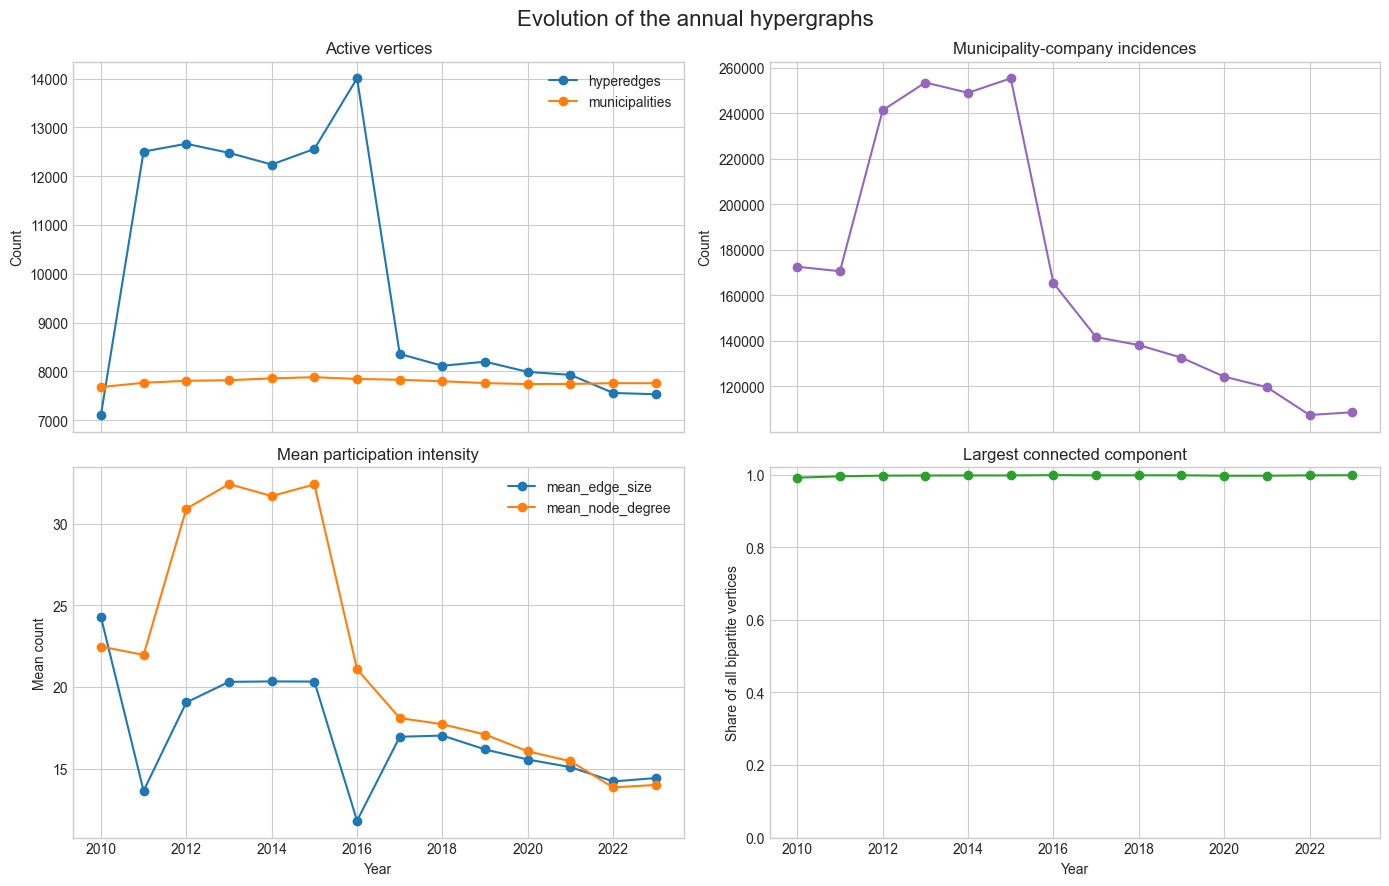

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

annual_stats[["hyperedges", "municipalities"]].plot(
    ax=axes[0, 0], marker="o"
)
axes[0, 0].set_title("Active vertices")
axes[0, 0].set_ylabel("Count")

annual_stats["incidences"].plot(ax=axes[0, 1], marker="o", color="tab:purple")
axes[0, 1].set_title("Municipality-company incidences")
axes[0, 1].set_ylabel("Count")

annual_stats[["mean_edge_size", "mean_node_degree"]].plot(
    ax=axes[1, 0], marker="o"
)
axes[1, 0].set_title("Mean participation intensity")
axes[1, 0].set_ylabel("Mean count")
axes[1, 0].set_xlabel("Year")

annual_stats["largest_component_share"].plot(
    ax=axes[1, 1], marker="o", color="tab:green"
)
axes[1, 1].set_title("Largest connected component")
axes[1, 1].set_ylabel("Share of all bipartite vertices")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylim(0, 1.02)

fig.suptitle("Evolution of the annual hypergraphs", fontsize=16)
fig.tight_layout()
plt.show()

## Year-to-year turnover

Jaccard similarity is intersection divided by union. Values near 1 mean two consecutive years retain nearly the same objects; values near 0 mean high turnover. Incidence similarity is the strictest measure because the same municipality-company pair must persist.

,year_from,municipality_jaccard,hyperedge_jaccard,incidence_jaccard,new_municipalities,lost_municipalities,new_hyperedges,lost_hyperedges,new_incidences,lost_incidences
year_to,,,,,,,,,,
2011,2010,0.986,0.495,0.434,99,10,6011,612,66721,68691
2012,2011,0.990,0.799,0.559,58,18,1484,1324,93664,22977
2013,2012,0.992,0.837,0.710,36,24,1026,1212,47978,35796
2014,2013,0.989,0.798,0.726,64,26,1271,1510,37641,42162
2015,2014,0.978,0.789,0.664,100,76,1618,1299,54116,47760
2016,2015,0.981,0.681,0.444,58,94,3242,1795,36026,125911
2017,2016,0.988,0.534,0.655,38,55,574,6223,20086,43843
2018,2017,0.988,0.883,0.789,34,64,390,632,14776,18261
2019,2018,0.986,0.854,0.772,36,74,683,599,14637,20190


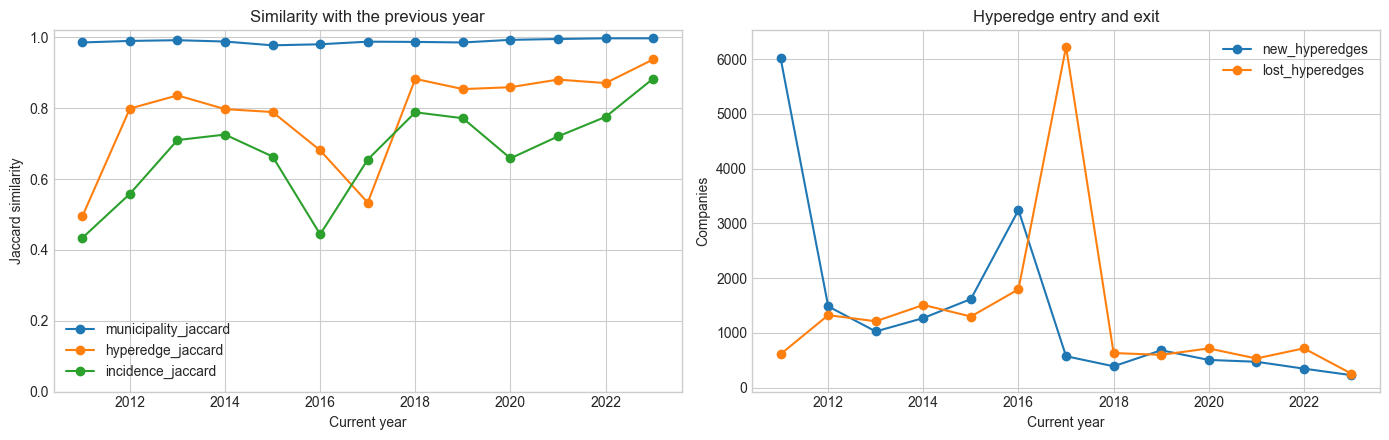

In [6]:
if turnover.empty:
    print("Turnover needs at least two available years.")
else:
    display(turnover)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    turnover[["municipality_jaccard", "hyperedge_jaccard", "incidence_jaccard"]].plot(
        ax=axes[0], marker="o"
    )
    axes[0].set_title("Similarity with the previous year")
    axes[0].set_xlabel("Current year")
    axes[0].set_ylabel("Jaccard similarity")
    axes[0].set_ylim(0, 1.02)

    turnover[["new_hyperedges", "lost_hyperedges"]].plot(
        ax=axes[1], marker="o"
    )
    axes[1].set_title("Hyperedge entry and exit")
    axes[1].set_xlabel("Current year")
    axes[1].set_ylabel("Companies")

    fig.tight_layout()
    plt.show()


## Degree distributions

The complementary cumulative distribution function (CCDF) shows the share of observations greater than or equal to each value. Log scales make the heavy tail visible without drawing the full graph.

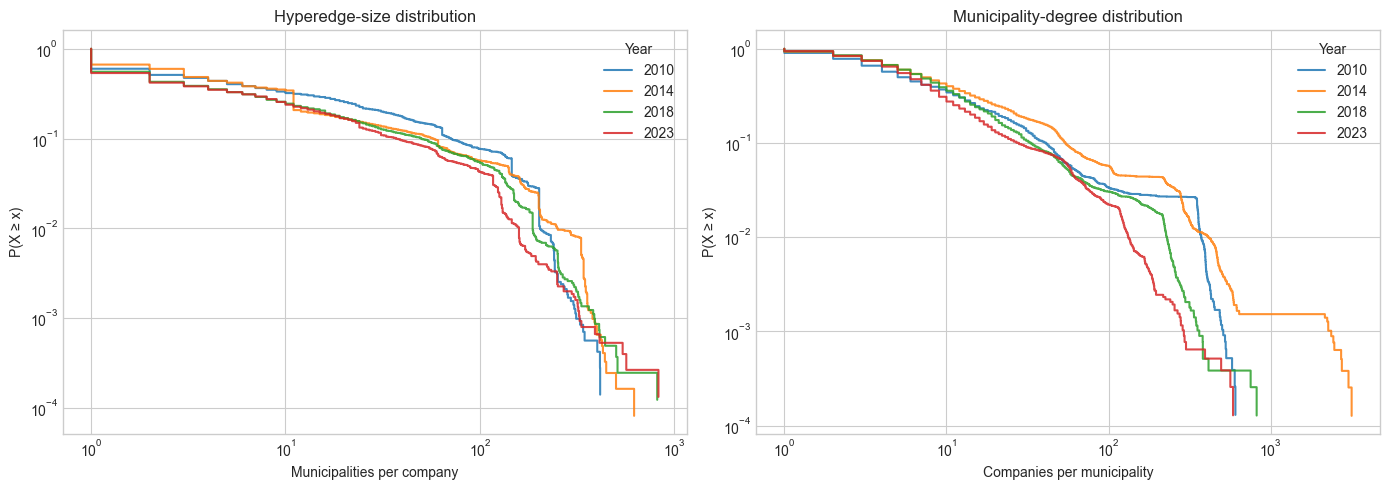

In [7]:
def plot_ccdf(series, ax, label):
    values = np.sort(np.asarray(series, dtype=float))
    survival = (len(values) - np.arange(len(values))) / len(values)
    ax.step(values, survival, where="post", label=str(label), alpha=0.85)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for year in DISTRIBUTION_YEARS:
    plot_ccdf(edge_size_distributions[year], axes[0], year)
    plot_ccdf(node_degree_distributions[year], axes[1], year)

for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("P(X ≥ x)")
    ax.legend(title="Year")

axes[0].set_title("Hyperedge-size distribution")
axes[0].set_xlabel("Municipalities per company")
axes[1].set_title("Municipality-degree distribution")
axes[1].set_xlabel("Companies per municipality")
fig.tight_layout()
plt.show()

## Detailed view of one year

The first company ranking is purely structural. The second uses the real company-size parameter prepared from the *Partecipate* workbook; it should be interpreted together with its data-quality fields. Municipality rankings include the annual population joined through the BDAP registry.
The prepared mean-one parameter columns shown here describe the full yearly input data. Experiment weights are tempered and normalized again on the filtered network by the shared runner loader.


In [8]:
selected = load_year(SELECTED_YEAR)
parameters = pd.read_csv(DATA_DIR / "hyperedge_parameters.csv")
parameters = parameters.loc[parameters["year"].eq(SELECTED_YEAR)].copy()
node_parameters = pd.read_csv(DATA_DIR / "node_parameters.csv")
node_parameters = node_parameters.loc[
    node_parameters["year"].eq(SELECTED_YEAR)
].copy()

company_structure = (
    selected.groupby("CF Partecipata")
    .agg(
        municipalities=("CF Comune", "nunique"),
        total_quota=("Quota", "sum"),
        mean_quota=("Quota", "mean"),
        max_quota=("Quota", "max"),
    )
    .reset_index()
    .rename(columns={"CF Partecipata": "company_id"})
)

parameter_columns = [
    "company_id",
    "company_name",
    "company_size_score_0_100",
    "edge_parameter_mean_1",
    "company_size_data_confidence_0_1",
    "company_size_data_quality",
    "edge_parameter_basis",
]
company_view = company_structure.merge(
    parameters[parameter_columns], on="company_id", how="left", validate="one_to_one"
)

print(f"Top {TOP_N} hyperedges by number of municipalities in {SELECTED_YEAR}")
display(
    company_view.sort_values(
        ["municipalities", "edge_parameter_mean_1"], ascending=False
    ).head(TOP_N)
)

print(f"Top {TOP_N} hyperedges by company-size parameter in {SELECTED_YEAR}")
display(
    company_view.sort_values(
        ["edge_parameter_mean_1", "municipalities"], ascending=False
    ).head(TOP_N)
)

Top 20 hyperedges by number of municipalities in 2023


,company_id,municipalities,total_quota,mean_quota,max_quota,company_name,company_size_score_0_100,edge_parameter_mean_1,company_size_data_confidence_0_1,company_size_data_quality,edge_parameter_basis
6196,12236141003,830,94.470,0.114,2.731,ASMEL CONSORTILE SOC. CONS. A R.L.,64.725,1.324,1.000,high,company_size_direct
5324,5166621218,567,93.632,0.165,5.160,ASMENET SOC. CONS. A R. L.,37.530,0.768,1.000,high,company_size_direct
4920,4042120230,543,97.173,0.179,9.120,VIVERACQUA S.C. A R.L.,37.040,0.758,1.000,high,company_size_direct
2785,2230170025,413,84.426,0.204,18.575,ATO2ACQUE S.C.A.R.L.,12.953,0.489,0.675,medium,company_size_confidence_shrunk
3744,2776580025,391,86.429,0.221,16.253,BIELLA CASALE VERCELLI VALSESIA ACQUE SOCIETA'...,17.234,0.353,1.000,medium,company_size_direct
3919,2934390929,333,28.875,0.087,6.306,ABBANOA S.P.A,99.323,2.032,1.000,high,company_size_direct
3738,2770891204,326,0.498,0.002,0.009,LEPIDA S.P.A.,95.605,1.956,1.000,high,company_size_direct
1204,1349420529,324,33.444,0.103,3.499,SERVIZI ECOLOGICI INTEGRATI TOSCANA - SOCIETA'...,97.727,2.000,1.000,high,company_size_direct
2792,2234900187,321,90.364,0.282,19.282,PAVIA ACQUE S.R.L.,96.231,1.969,1.000,high,company_size_direct
3747,2778560041,319,59.626,0.187,33.000,MONDO ACQUA SPA,71.287,1.459,1.000,high,company_size_direct


Top 20 hyperedges by company-size parameter in 2023


,company_id,municipalities,total_quota,mean_quota,max_quota,company_name,company_size_score_0_100,edge_parameter_mean_1,company_size_data_confidence_0_1,company_size_data_quality,edge_parameter_basis
245,303490189,1,1.000,1.000,1.000,FONDAZIONE IRCCS POLICLINICO SAN MATTEO,99.957,2.045,1.000,low,company_size_direct
6177,11957540153,2,50.000,25.000,25.000,A2A S.P.A.,99.945,2.045,1.000,high,company_size_direct
5019,4245520376,10,39.077,3.908,12.599,HERA S.P.A.,99.912,2.044,1.000,high,company_size_direct
6255,13032990155,1,0.100,0.100,0.100,"""AEROPORTI DI ROMA S.P.A"" IN FORMA ABREVIATA ""...",99.825,2.042,1.000,high,company_size_direct
7448,97230720159,1,100.000,100.000,100.000,AZIENDA TRASPORTI MILANESI S.P.A. IN FORMA ABB...,99.797,2.042,1.000,high,company_size_direct
5508,5848061007,111,52.733,0.475,52.733,ACEA ATO 2 - GRUPPO ACEA - SOCIETA' PER AZIONI...,99.785,2.042,1.000,high,company_size_direct
5499,5816611007,1,51.000,51.000,51.000,ARETI S.P.A.,99.736,2.041,1.000,high,company_size_direct
6246,12883450152,2,50.000,25.000,25.000,UNARETI S.P.A.,99.719,2.040,1.000,high,company_size_direct
548,826040156,7,54.925,7.846,54.809,SOCIETA' PER AZIONI ESERCIZI AEROPORTUALI S.E.A.,99.685,2.040,1.000,high,company_size_direct
1984,1791490343,2,8.844,4.422,8.376,IRETI S.P.A.,99.623,2.038,1.000,high,company_size_direct


In [9]:
municipality_view = (
    selected.groupby("CF Comune")
    .agg(
        municipality_name=("Comune", "first"),
        companies=("CF Partecipata", "nunique"),
        total_quota=("Quota", "sum"),
        mean_quota=("Quota", "mean"),
    )
    .reset_index()
    .rename(columns={"CF Comune": "municipality_id"})
)
municipality_view = municipality_view.merge(
    node_parameters[[
        "municipality_id",
        "municipality_bdap_id",
        "population",
        "node_weight_mean_1",
        "node_weight_basis",
    ]],
    on="municipality_id",
    how="left",
    validate="one_to_one",
)

print(f"Top {TOP_N} municipalities by hypergraph degree in {SELECTED_YEAR}")
display(
    municipality_view.sort_values(
        ["companies", "total_quota"], ascending=False
    ).head(TOP_N)
)

print(f"Top {TOP_N} municipalities by population in {SELECTED_YEAR}")
display(
    municipality_view.sort_values(
        ["node_weight_mean_1", "companies"], ascending=False
    ).head(TOP_N)
)

Top 20 municipalities by hypergraph degree in 2023


,municipality_id,municipality_name,companies,total_quota,mean_quota,municipality_bdap_id,population,node_weight_mean_1,node_weight_basis
686,168650307,COMUNE DI UDINE,585,572.830,0.979,"235,142,930,547,606,816.000","98,430.000",13.124,population_direct
4021,1307110484,COMUNE DI FIRENZE,563,"1,363.449",2.422,"327,042,930,518,364,928.000","363,837.000",48.510,population_direct
3202,516890241,COMUNE DI VICENZA,494,"1,513.513",3.064,"901,542,930,540,856,448.000","110,830.000",14.777,population_direct
3746,761890177,COMUNE DI BRESCIA,393,"4,329.013",11.015,"246,042,930,508,095,392.000","198,688.000",26.491,population_direct
563,145920351,COMUNE DI REGGIO NELL'EMILIA,300,"1,999.025",6.663,"298,342,930,544,433,280.000","171,342.000",22.845,population_direct
4213,2253930156,COMUNE DI SESTO SAN GIOVANNI,294,403.074,1.371,"148,342,930,537,454,208.000","78,565.000",10.475,population_direct
3986,1199250158,COMUNE DI MILANO,291,"5,474.941",18.814,"882,942,930,528,952,832.000","1,371,850.000",182.909,population_direct
3251,524950177,COMUNE DI CALCINATO,286,109.139,0.382,"847,642,930,531,798,272.000","13,038.000",1.738,population_direct
3544,644060287,COMUNE DI PADOVA,279,720.351,2.582,"194,642,930,545,150,304.000","207,301.000",27.639,population_direct
3547,645400177,COMUNE DI MONTICHIARI,278,200.181,0.720,"995,642,930,452,472,576.000","26,367.000",3.516,population_direct


Top 20 municipalities by population in 2023


,municipality_id,municipality_name,companies,total_quota,mean_quota,municipality_bdap_id,population,node_weight_mean_1,node_weight_basis
4246,2438750586,ROMA CAPITALE,172,"5,416.057",31.489,"928,842,930,532,139,904.000","2,754,719.000",367.287,population_direct
3986,1199250158,COMUNE DI MILANO,291,"5,474.941",18.814,"882,942,930,528,952,832.000","1,371,850.000",182.909,population_direct
5425,80014890638,COMUNE DI NAPOLI,128,"1,198.768",9.365,"582,842,930,527,808,640.000","911,697.000",121.557,population_direct
3198,514490010,COMUNE DI TORINO,84,"2,756.812",32.819,"409,242,930,459,718,208.000","846,926.000",112.921,population_direct
5447,80016350821,COMUNE DI PALERMO,18,"1,472.057",81.781,"506,842,930,543,580,992.000","628,894.000",83.850,population_direct
3841,856930102,COMUNE DI GENOVA,47,"2,103.849",44.763,"368,442,930,519,901,376.000","561,947.000",74.924,population_direct
4003,1232710374,COMUNE DI BOLOGNA,224,"2,209.400",9.863,"935,842,930,534,066,688.000","390,518.000",52.068,population_direct
4021,1307110484,COMUNE DI FIRENZE,563,"1,363.449",2.422,"327,042,930,518,364,928.000","363,837.000",48.510,population_direct
5427,80015010723,COMUNE DI BARI,135,686.126,5.082,"289,742,930,530,454,976.000","316,212.000",42.161,population_direct
513,137020871,COMUNE DI CATANIA,33,975.794,29.570,"555,142,930,521,219,072.000","298,209.000",39.760,population_direct


## Parameter data quality over time

This final diagnostic distinguishes structural change from changes in the availability of company accounting data. A neutral parameter is the within-year median fallback, not evidence that the company is truly average-sized.

,company_size_available_pct,neutral_parameter_fallback_pct,exact_company_record_pct,population_available_pct
year,,,,
2010,84.053,15.947,99.916,95.910
2011,72.489,27.511,99.992,95.931
2012,75.047,24.953,99.984,95.990
2013,76.903,23.097,99.984,96.009
2014,78.814,21.186,100.000,95.876
2015,78.627,21.373,100.000,96.548
2016,74.088,25.912,100.000,97.055
2017,92.652,7.348,99.952,97.355
2018,93.123,6.877,99.951,97.602


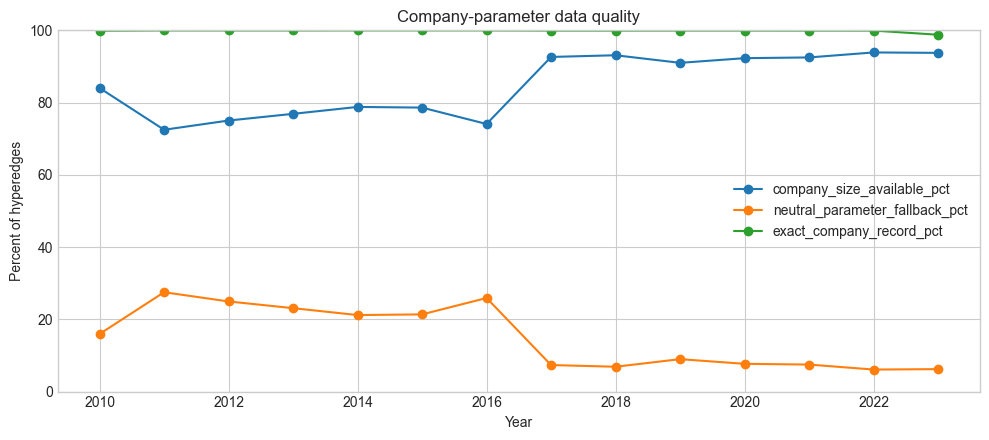

In [10]:
quality_path = DATA_DIR / "data_quality_by_year.csv"
if quality_path.exists():
    data_quality = pd.read_csv(quality_path).set_index("year")
    display(
        data_quality[[
            "company_size_available_pct",
            "neutral_parameter_fallback_pct",
            "exact_company_record_pct",
            "population_available_pct",
        ]]
    )

    ax = data_quality[[
        "company_size_available_pct",
        "neutral_parameter_fallback_pct",
        "exact_company_record_pct",
    ]].plot(figsize=(10, 4.5), marker="o")
    ax.set_title("Company-parameter data quality")
    ax.set_xlabel("Year")
    ax.set_ylabel("Percent of hyperedges")
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()
else:
    print("No data-quality summary found. Run `python src/prepare_data.py`.")

## Reading the results

Useful signals to compare are: growth or contraction in active municipalities and companies; shifts in mean and tail degree; the fraction captured by the largest component; and discontinuities in year-to-year Jaccard similarity. Check low-similarity years against the data-quality plot before interpreting them as real institutional changes.